<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/Chapter7_01_%EC%99%80%EC%9D%B8_%ED%92%88%EC%A7%88_%EB%93%B1%EA%B8%89_%EC%98%88%EC%B8%A1%ED%95%98%EA%B8%B0_2026_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

프로젝트 1. [기술통계분석 + 그래프] - 와인품질등급 예측하기  

#1. 엑셀에서 열 구분자를 세미콜론으로 인식시키기

In [2]:
import pandas as pd

# 'winequality-red.csv' 파일은 일반적으로 쉼표(,)로 구분됩니다.
# 또한, red_df는 winequality-red.csv에서 로드하는 것이 일반적입니다.
red_df = pd.read_csv('winequality-red.csv', sep = ';', header = 0, engine = 'python')

# 'winequality-white.csv' 파일도 일반적으로 쉼표(,)로 구분됩니다.
white_df = pd.read_csv('winequality-white.csv', sep = ';', header = 0, engine= 'python')

red_df.to_csv('winequality-red2.csv', index = False)
white_df.to_csv('winequality-white2.csv', index = False)

# 4.2 데이터 병합하기
# 1. 레드 와인과 화이트 와인 파일 합치기

In [4]:
red_df.head()

# 'type' 컬럼이 존재하지 않을 때만 삽입합니다.
if 'type' not in red_df.columns:
    red_df.insert(0, column = 'type', value = 'red')

red_df.head()

red_df.shape

white_df.head()

# 'type' 컬럼이 존재하지 않을 때만 삽입합니다.
if 'type' not in white_df.columns:
    white_df.insert(0, column = 'type', value = 'white')

white_df.head()

white_df.shape

wine = pd.concat([red_df, white_df])

wine.shape

wine.to_csv('wine.csv', index = False)

#5 데이터 탐색 -----------------------------------------

#1. 기본 정보 확인하기


In [5]:
print(wine.info())

<class 'pandas.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   str    
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), str(1)
memory usage: 710.6 KB
None


#2. 함수를 사용해 기술 통계 구하기

In [6]:
wine.columns = wine.columns.str.replace(' ', '_') #
wine.head()
wine.describe()
sorted(wine.quality.unique())
wine.quality.value_counts()


quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

# 6 데이터 모델링 -----------------------------------

# 6.1 describe( ) 함수로 그룹 비교하기


In [7]:
wine.groupby('type')['quality'].describe()
wine.groupby('type')['quality'].mean()
wine.groupby('type')['quality'].std()
wine.groupby('type')['quality'].agg(['mean', 'std'])


,mean,std
type,,
red,5.636023,0.807569
white,5.877909,0.885639


# 6.2 t-검정과 회귀 분석으로 그룹 비교하기
### cmd창에서 통계패키지 설치하기:  


In [8]:
!pip install statsmodels
from scipy import stats
from statsmodels.formula.api import ols, glm
red_wine_quality = wine.loc[wine['type'] == 'red', 'quality']
white_wine_quality = wine.loc[wine['type'] == 'white', 'quality']
stats.ttest_ind(red_wine_quality, white_wine_quality, equal_var = False)

Rformula = 'quality ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + sulphates + alcohol'

regression_result = ols(Rformula, data = wine).fit()

regression_result.summary()



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 5.6 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 5.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 6.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.5 MB 5.1 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 4.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 4.4 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    ---------------------

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     243.3
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:31:43   Log-Likelihood:                -7215.5
No. Observations:                6497   AIC:                         1.445e+04
Df Residuals:                    6485   BIC:                         1.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               55.7627     11.894      4.688      0.000      32.447      79.079
fixed_acidity            0.0677      0.016      4.346      0.000       0.037       0.098
volatile_acidity        -1.3279      0.077    -17.162      0.000      -1.480      -1.176
citric_acid             -0.1097      0.080     -1.377      0.168      -0.266       0.046
residual_sugar           0.0436      0.005      8.449      0.000       0.033       0.054
chlorides               -0.4837      0.333     -1.454      0.146      -1.136       0.168
free_sulfur_dioxide      0.0060      0.001      7.948      0.000       0.004       0.007
total_sulfur_dioxide    -0.0025      0.000     -8.969      0.000      -0.003      -0.002
density                -54.9669     12.137     -4.529      0.000     -78.760     -31.173
pH                       0.4393      0.090      4.861      0.000       0.262       0.616
sulphates                0.7683      0.076     10.092      0.000       0.619       0.917
alcohol                  0.2670      0.017     15.963      0.000       0.234       0.300
==============================================================================
Omnibus:                      144.075   Durbin-Watson:                   1.646
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.712
Skew:                          -0.006   Prob(JB):                     3.09e-71
Kurtosis:                       4.095   Cond. No.                     2.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


# 6.3 회귀 분석 모델로 새로운 샘플의 품질 등급 예측하기


In [9]:
sample1 = wine[wine.columns.difference(['quality', 'type'])]
sample1 = sample1[0:5][:]
sample1_predict = regression_result.predict(sample1)
sample1_predict
wine[0:5]['quality']

data = {"fixed_acidity" : [8.5, 8.1], "volatile_acidity":[0.8, 0.5],
"citric_acid":[0.3, 0.4], "residual_sugar":[6.1, 5.8], "chlorides":[0.055,
0.04], "free_sulfur_dioxide":[30.0, 31.0], "total_sulfur_dioxide":[98.0,
99], "density":[0.996, 0.91], "pH":[3.25, 3.01], "sulphates":[0.4, 0.35],
"alcohol":[9.0, 0.88]}

sample2 = pd.DataFrame(data, columns= sample1.columns)
sample2


sample2_predict = regression_result.predict(sample2)
sample2_predict



0    4.809094
1    7.582129
dtype: float64

# 7 결과 시각화 --------------------------------------------
#7.1 와인 유형에 따른 품질 등급 히스토그램 그리기
###cmd 창에서 패키지 설치하기:



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


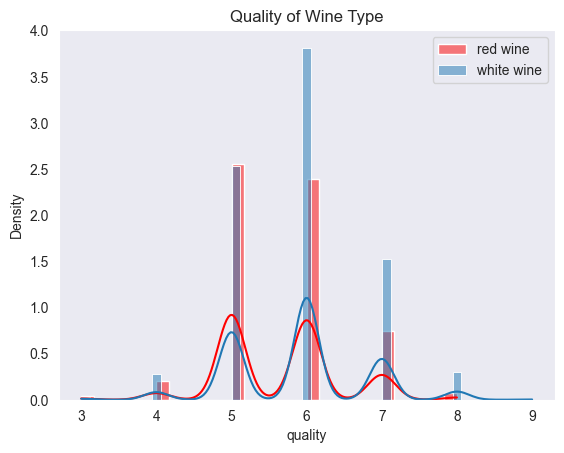

In [10]:
!pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('dark')

sns.histplot(red_wine_quality, stat='density', kde = True, color = "red", label = 'red wine')
sns.histplot(white_wine_quality, stat='density', kde = True, label = 'white wine')
plt.title("Quality of Wine Type")
plt.legend()
plt.show()



#7.2 부분 회귀 플롯으로 시각화하기

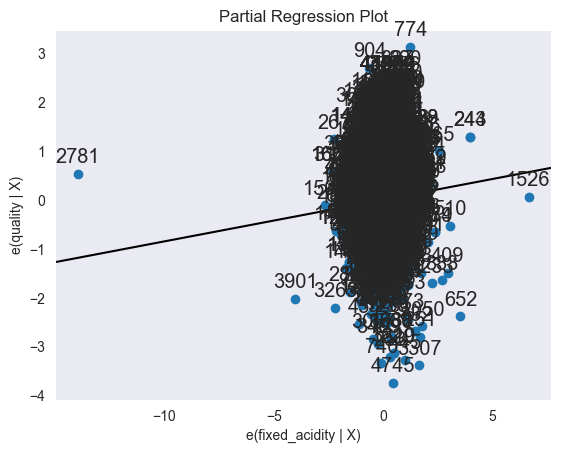

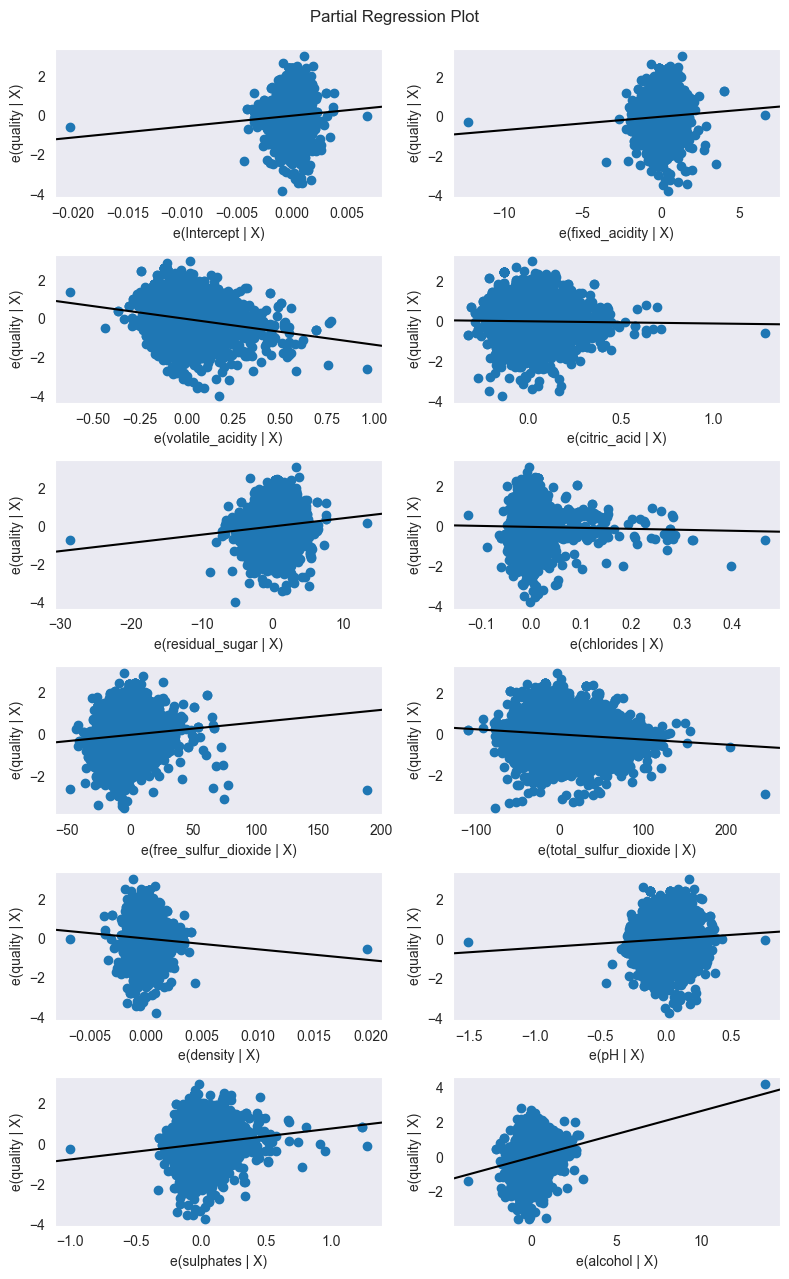

In [11]:
import statsmodels.api as sm
others = list(set(wine.columns).difference(set(["quality", "fixed_acidity"])))
p, resids = sm.graphics.plot_partregress("quality", "fixed_acidity", others, data = wine, ret_coords = True)
plt.show()

fig = plt.figure(figsize = (8, 13))
sm.graphics.plot_partregress_grid(regression_result, fig = fig)
plt.show()

